In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Question 1: Correlation Matrix & Heatmap

In [2]:
# Load data
df = pd.read_csv('Housing.csv')

In [3]:
# 1. Isolate numerical columns only
num_df = df.select_dtypes(include=['number'])

In [4]:
# 2. Compute correlation matrix
corr_matrix = num_df.corr()

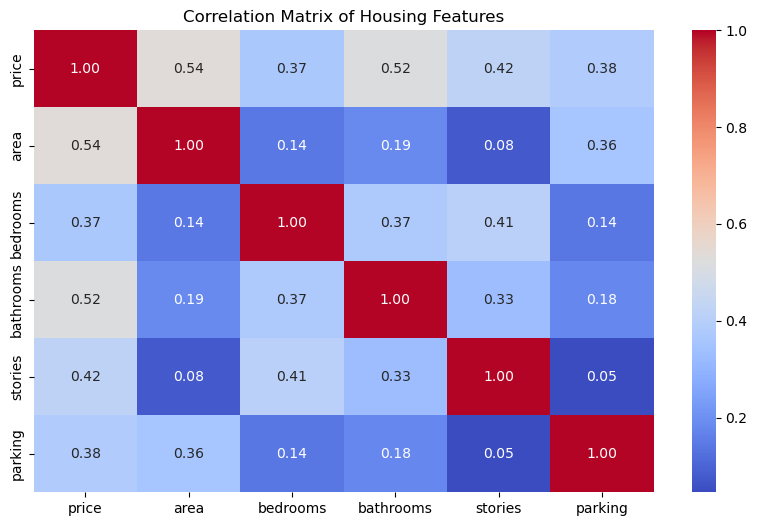

In [5]:
# 3. Plot the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Housing Features")
plt.show()

Q: Strongest positive correlation with price?
A: Look at the 'price' row/column. Find the highest number (closest to +1.0) excluding price itself. (Which is 'area').

Q: Weakest relationship?
A: Find the number closest to 0.00 anywhere on the board (e.g., between bedrooms and stories, or similar).

Question 2: Independent T-Test (Air Conditioning)

Null Hypothesis: There is NO significant difference in average price between houses with and without AC.

 Alternative Hypothesis: There IS a significant difference in average price between houses with and without AC.

In [6]:
from scipy import stats

In [7]:
# 1. Divide data into two groups based on AC
ac_yes = df[df['airconditioning'] == 'yes']['price']
ac_no = df[df['airconditioning'] == 'no']['price']

In [8]:
# 2. Perform independent t-test
t_stat, p_value = stats.ttest_ind(ac_yes, ac_no)

In [9]:
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value}") # Note: e-xx means scientific notation (move decimal left xx times)

T-statistic: 11.84
P-value: 6.310969853530074e-29


In [10]:
# 3. Interpretation Rule
alpha = 0.05
if p_value < alpha:
    print("\nDecision: Reject Null Hypothesis (H0)")
    print("Conclusion: Air conditioning significantly affects house prices.")
else:
    print("\nDecision: Fail to reject Null Hypothesis (H0)")
    print("Conclusion: No significant price difference based on AC.")


Decision: Reject Null Hypothesis (H0)
Conclusion: Air conditioning significantly affects house prices.


Question 3: Z-Test (Population Mean)

Null Hypothesis: The average house price is exactly 7,000,000.

Alternative Hypothesis: The average house price is NOT 7,000,000.

In [11]:
# To do a Z-test easily in Python, we import statsmodels
from statsmodels.stats.weightstats import ztest

In [12]:
# 1. Define the population mean we are testing against
pop_mean_claim = 7000000

In [13]:
# 2. Compute Z-score and P-value
z_stat, p_value_z = ztest(df['price'], value=pop_mean_claim)

In [14]:
print(f"Z-score: {z_stat:.2f}")
print(f"P-value: {p_value_z:.4f}")

Z-score: -27.87
P-value: 0.0000


In [15]:
# 3. Interpretation at 5% significance level
if p_value_z < 0.05:
    print("\nDecision: Reject Null Hypothesis (H0)")
    print("Conclusion: The average house price is significantly different from 7,000,000.")
else:
    print("\nDecision: Fail to reject Null Hypothesis (H0)")
    print("Conclusion: The average house price is not significantly different from 7,000,000.")


Decision: Reject Null Hypothesis (H0)
Conclusion: The average house price is significantly different from 7,000,000.


Question 4: Chi-Square Test (Categorical Independence)

Null Hypothesis: Furnishing status and preferred area are independent (NO relationship).

Alternative Hypothesis: Furnishing status and preferred area are dependent (A relationship exists).

In [16]:
# 1. Create a contingency table (crosstab)
contingency_table = pd.crosstab(df['furnishingstatus'], df['prefarea'])
print("--- Contingency Table ---")
print(contingency_table)

--- Contingency Table ---
prefarea           no  yes
furnishingstatus          
furnished          96   42
semi-furnished    174   52
unfurnished       145   33


In [17]:
# 2. Perform Chi-Square Test
chi2_stat, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

In [18]:
print(f"\nChi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value_chi:.4f}")


Chi-Square Statistic: 6.17
P-value: 0.0457


In [19]:
# 3. Interpretation
if p_value_chi < 0.05:
    print("\nDecision: Reject Null Hypothesis (H0)")
    print("Conclusion: A relationship exists between furnishing status and preferred area.")
else:
    print("\nDecision: Fail to reject Null Hypothesis (H0)")
    print("Conclusion: No relationship. Furnishing status and preferred area are independent.")


Decision: Reject Null Hypothesis (H0)
Conclusion: A relationship exists between furnishing status and preferred area.
